<a href="https://colab.research.google.com/github/qazianwar7/World-Happiness-Predictor/blob/main/happiness_score_capstone_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1 and 2 downloading and importing libraries

In [4]:
#step 1 downloading all the libraries required
!pip install pandas numpy matplotlib seaborn scikit-learn streamlit joblib

In [5]:
#step 2 importing all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
import joblib

In [6]:
#step 3 loading all datasets
df1 = pd.read_csv('2015.csv')
df2 = pd.read_csv('2016.csv')
df3 = pd.read_csv('2017.csv')
df4 = pd.read_csv('2018.csv')
df5 = pd.read_csv('2019.csv')

dataframes = [df1, df2, df3, df4, df5]

# Step 4 EDA, Colunm information, missing values, datatypes, check duplicates, correlation heatmap, regression and classification



   df1   
       Country          Region  Happiness Rank  Happiness Score  \
0  Switzerland  Western Europe               1            7.587   
1      Iceland  Western Europe               2            7.561   
2      Denmark  Western Europe               3            7.527   
3       Norway  Western Europe               4            7.522   
4       Canada   North America               5            7.427   

   Standard Error  Economy (GDP per Capita)   Family  \
0         0.03411                   1.39651  1.34951   
1         0.04884                   1.30232  1.40223   
2         0.03328                   1.32548  1.36058   
3         0.03880                   1.45900  1.33095   
4         0.03553                   1.32629  1.32261   

   Health (Life Expectancy)  Freedom  Trust (Government Corruption)  \
0                   0.94143  0.66557                        0.41978   
1                   0.94784  0.62877                        0.14145   
2                   0.87464  0.64938

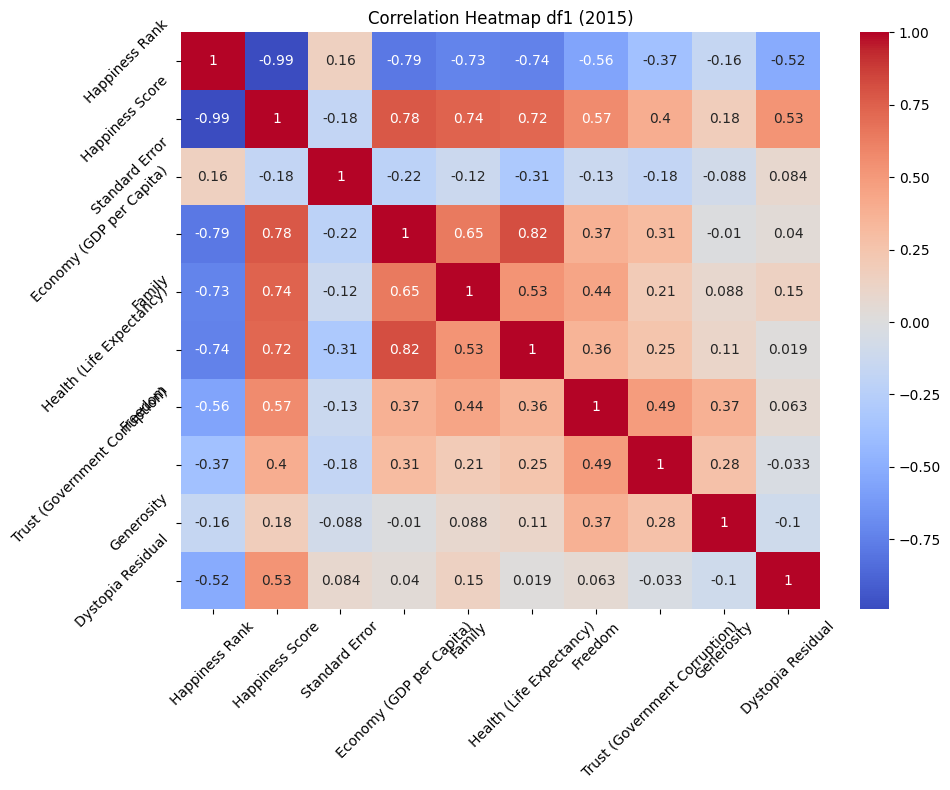

regression


In [7]:

#EDA

for i, df in enumerate(dataframes, start = 1):
  print(f'\n   df{i}   ')
  print(df.head())
  print(df.info())
  print(df.describe())

#colunm information

for i,df in enumerate(dataframes, start = 1):
  name_col = list(df.columns)
  num_col = len(df.columns)
  print(f'\ndf{i} columns :{name_col}')
  print(f'Total columns: {num_col}')

#finding missing values

for i,df in enumerate(dataframes, start = 1):
  print(f'\ndf{i} missing values:')
  print(df.isnull().sum())

#fix missing values

for i,df in enumerate(dataframes, start = 1):
  dataframes[i-1] = df.fillna(df.mean(numeric_only = True))
  print(f'df{i} missing values fixed')

#checking datatypes

for i,df in enumerate(dataframes, start = 1):
  print(f'\ndf{i} datatypes:')
  print(df.dtypes)

#checking duplicates

def check_and_remove_duplicates(df):
  duplicates = df.columns[df.columns.duplicated()].tolist()
  print (f'duplicates found: {duplicates}' if duplicates else 'No duplicates found')
  return df.loc[:,~df.columns.duplicated()]

for i,df in enumerate(dataframes, start = 1):
  print(f'\ndf{i} duplicates:')
  check_and_remove_duplicates(df)

#correlation heatmap

numeric_df1 = df1.select_dtypes(include= 'number')
corr = numeric_df1.corr()
plt.figure(figsize = (10,8))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap df1 (2015)')
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.tight_layout()
plt.show()

# check regrssion and classification

def check_problem_type(df, target_col):
  target_data = df[target_col]
  unique_values = df[target_col].nunique()
  if target_data.dtype in ['int64', 'float64']:
    return "regression" if unique_values > 10 else "classification"

#for exapmle
print (check_problem_type(df1, 'Happiness Score'))

#regression (output)

# step 5 Descriptive analysis

#average happiness graph

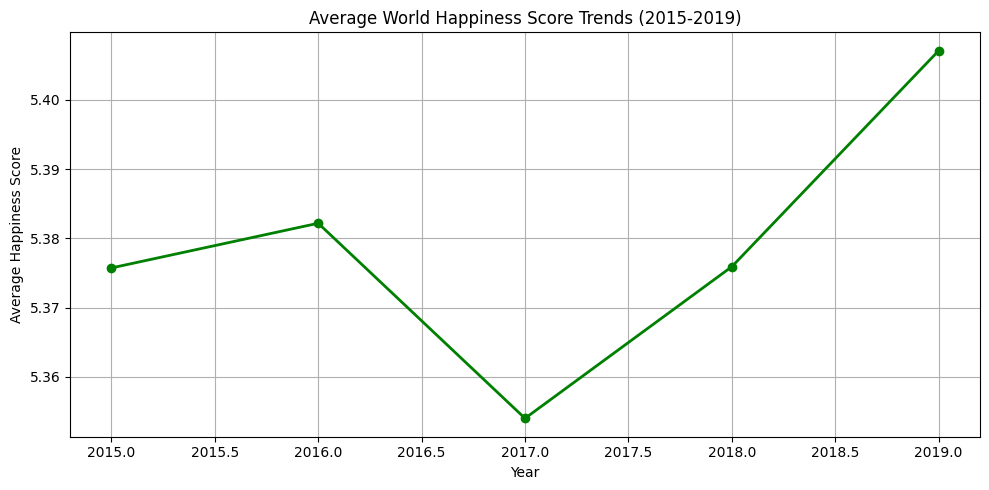

In [8]:
#average happiness graph
# Add year column to each df
years = [2015, 2016, 2017, 2018, 2019]
score_cols = ['Happiness Score', 'Happiness Score',
              'Happiness.Score', 'Score', 'Score']

avg_scores = []
for df, col in zip(dataframes, score_cols):
    avg_scores.append(df[col].mean())

plt.figure(figsize=(10, 5))
plt.plot(years, avg_scores, marker='o', color='green', linewidth=2)
plt.title('Average World Happiness Score Trends (2015-2019)')
plt.xlabel('Year')
plt.ylabel('Average Happiness Score')
plt.grid(True)
plt.tight_layout()
plt.show()

#top 10 and bottom 10 happy countires graph


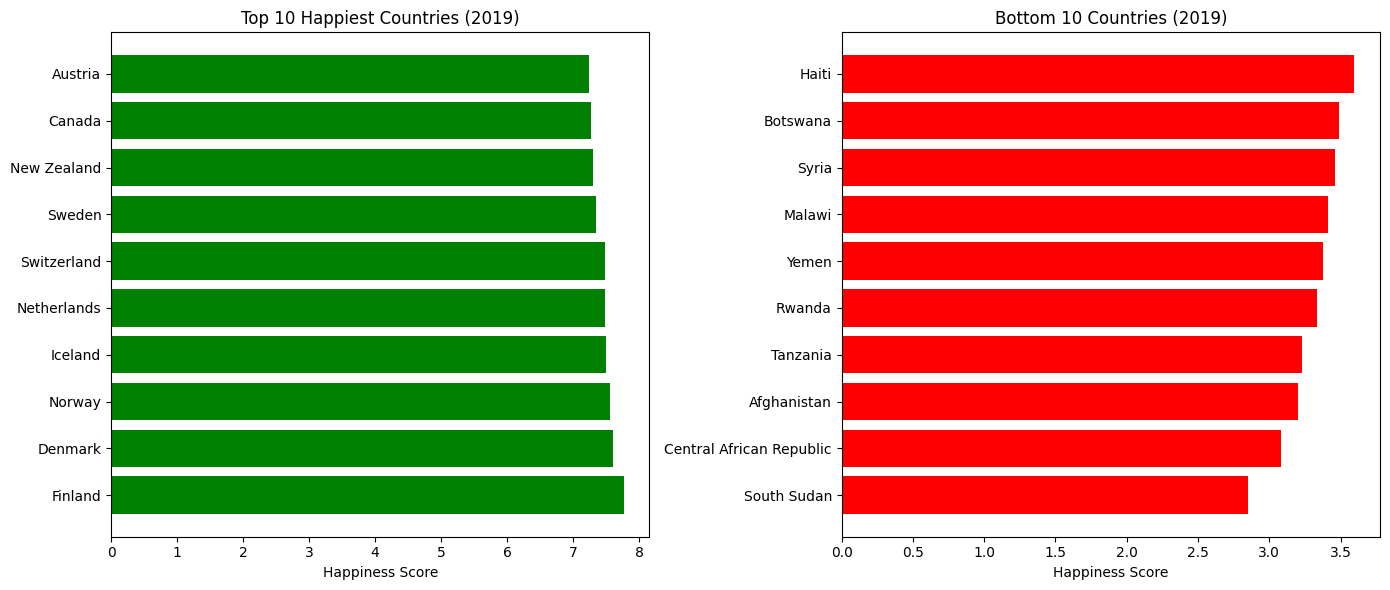

In [9]:
#top 10 and bottom 10 happy countires graph

top10 = df5.nlargest(10, 'Score')
bottom10 = df5.nsmallest(10, 'Score')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top10['Country or region'], top10['Score'], color='green')
axes[0].set_title('Top 10 Happiest Countries (2019)')
axes[0].set_xlabel('Happiness Score')

axes[1].barh(bottom10['Country or region'], bottom10['Score'], color='red')
axes[1].set_title('Bottom 10 Countries (2019)')
axes[1].set_xlabel('Happiness Score')

plt.tight_layout()
plt.show()

# GDP VS Happiness Scatter plot

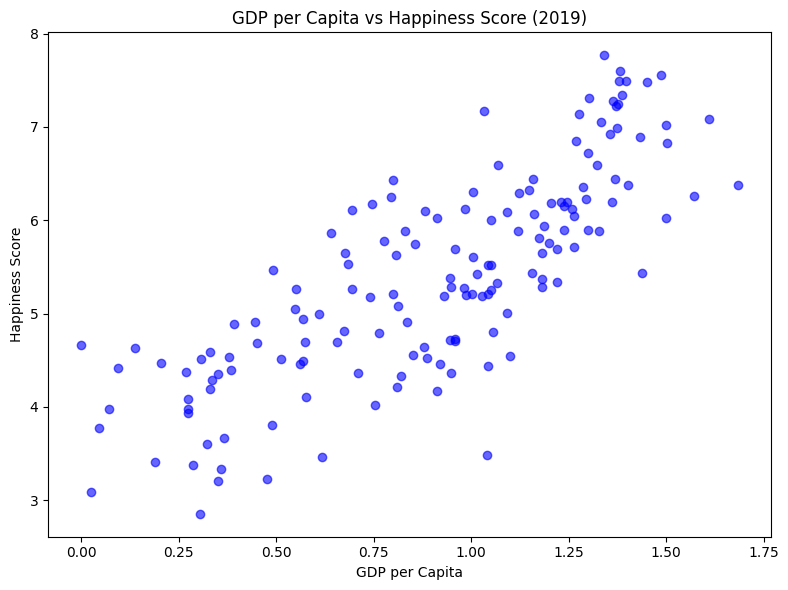

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(df5['GDP per capita'], df5['Score'], color='blue', alpha=0.6)
plt.title('GDP per Capita vs Happiness Score (2019)')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')
plt.tight_layout()
plt.show()

# distribution of happiness score

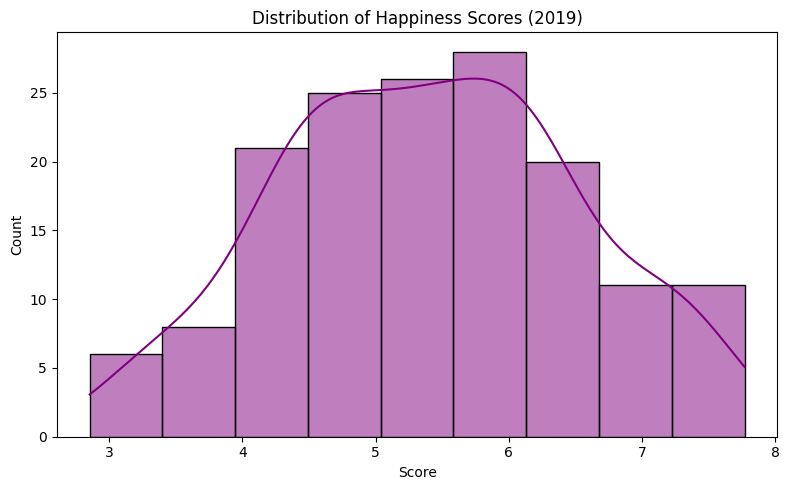

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df5['Score'], kde=True, color='purple')
plt.title('Distribution of Happiness Scores (2019)')
plt.xlabel('Score')
plt.tight_layout()
plt.show()

# feature contribution (average bar graph)

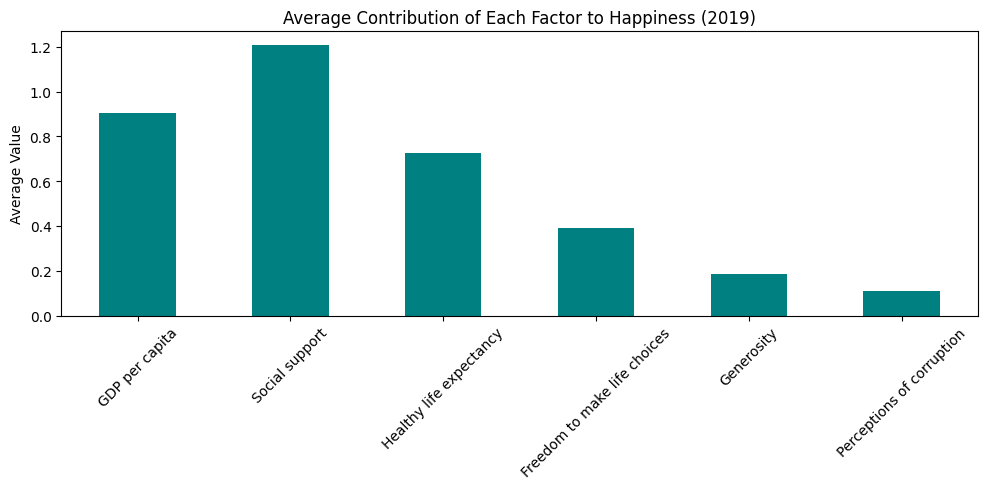

In [12]:
features = ['GDP per capita', 'Social support',
            'Healthy life expectancy',
            'Freedom to make life choices',
            'Generosity',
            'Perceptions of corruption']

avg_vals = df5[features].mean()

plt.figure(figsize=(10, 5))
avg_vals.plot(kind='bar', color='teal')
plt.title('Average Contribution of Each Factor to Happiness (2019)')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 6 : Model building (Predictive Analysis)

MAE:  0.4955
MSE:  0.4145
RMSE: 0.6438
R²:   0.6018


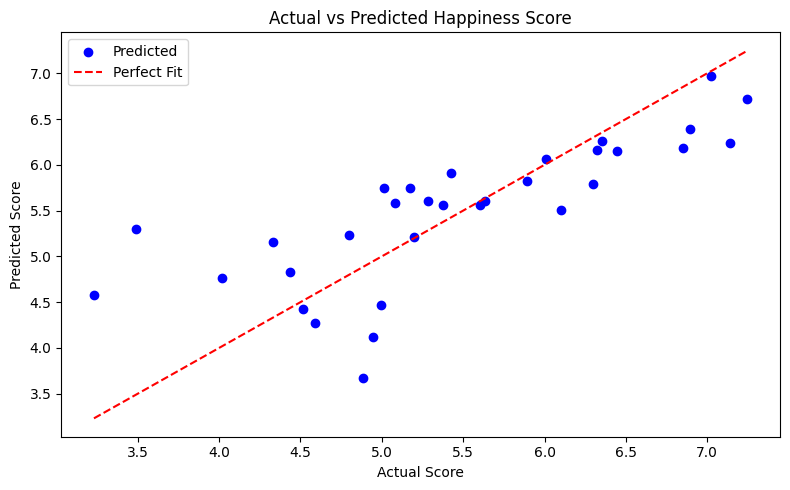

In [13]:
# Use df5 (2019) for modeling
features = ['GDP per capita', 'Social support',
            'Healthy life expectancy',
            'Freedom to make life choices',
            'Generosity',
            'Perceptions of corruption']
target = 'Score'

X = df5[features]
y = df5[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluation
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f'MAE:  {mae:.4f}')
print(f'MSE:  {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R²:   {r2:.4f}')

# Actual vs Predicted Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', label='Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')
plt.title('Actual vs Predicted Happiness Score')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.legend()
plt.tight_layout()
plt.show()

#step 7 saving the model


In [14]:
#step 7 saving the model

joblib.dump(model, 'happiness_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
print('model saved')

model saved


# step 8 streamlit app

In [15]:
!pip install -q streamlit
!npm install localtunnel


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
added 22 packages in 2s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋

In [16]:
%%writefile app.py
import streamlit as st
import numpy as np
import joblib
import pandas as pd

# --- Page Configuration ---
st.set_page_config(page_title="Happiness Predictor", page_icon="🌍", layout="centered")

# --- Load Model & Scaler ---
# We use st.cache_resource so it only loads the files once, making the app much faster
@st.cache_resource
def load_models():
    model = joblib.load('happiness_model.joblib')
    scaler = joblib.load('scaler.joblib')
    return model, scaler

try:
    model, scaler = load_models()
except FileNotFoundError:
    st.error("⚠️ Model or Scaler not found! Please make sure you saved 'happiness_model.joblib' and 'scaler.joblib' in this Colab session.")
    st.stop()

# --- Main Header ---
st.title('🌍 World Happiness Score Predictor')
st.markdown("""
Welcome! This tool uses a Machine Learning model trained on the **World Happiness Report** to predict a country's happiness score based on 6 key indicators.
*Adjust the sliders in the sidebar to see how different factors affect the final score.*
""")
st.divider()

# --- Sidebar Inputs ---
st.sidebar.header("⚙️ Adjust Indicators")
st.sidebar.write("Slide to set the country's metrics:")

# Added tooltips (help="") to explain what each metric means
gdp        = st.sidebar.slider('GDP per Capita',          0.0, 2.5, 1.0, 0.01, help="Economic production of a country")
social     = st.sidebar.slider('Social Support',          0.0, 2.0, 1.0, 0.01, help="Having someone to count on in times of trouble")
health     = st.sidebar.slider('Healthy Life Expectancy', 0.0, 1.5, 0.8, 0.01, help="Life expectancy at birth")
freedom    = st.sidebar.slider('Freedom',                 0.0, 1.0, 0.5, 0.01, help="Freedom to make life choices")
generosity = st.sidebar.slider('Generosity',              0.0, 1.0, 0.2, 0.01, help="Donations to charity, etc.")
corruption = st.sidebar.slider('Perceptions of Corruption',0.0, 1.0, 0.1, 0.01, help="Perceived lack of corruption in government/business")

st.sidebar.markdown("---")
st.sidebar.caption("By Qazi Anwar Ahmad")

# --- Main Content: Input Summary ---
st.subheader("Current Input Summary")
col1, col2, col3 = st.columns(3)
col1.metric("GDP per Capita", f"{gdp:.2f}")
col2.metric("Social Support", f"{social:.2f}")
col3.metric("Life Expectancy", f"{health:.2f}")

col4, col5, col6 = st.columns(3)
col4.metric("Freedom", f"{freedom:.2f}")
col5.metric("Generosity", f"{generosity:.2f}")
col6.metric("Corruption", f"{corruption:.2f}")

st.divider()

# --- Prediction Logic ---
if st.button('🔮 Predict Happiness Score', use_container_width=True):
    # Format inputs for the model
    input_data = np.array([[gdp, social, health, freedom, generosity, corruption]])
    input_scaled = scaler.transform(input_data)

    # Make prediction
    prediction = model.predict(input_scaled)[0]

    # Display dynamic results based on the score
    st.subheader("Prediction Result")
    if prediction >= 6.5:
        st.success(f"### 🎉 Predicted Happiness Score: {prediction:.2f}")
        st.balloons()
    elif prediction >= 4.5:
        st.info(f"### 😐 Predicted Happiness Score: {prediction:.2f}")
    else:
        st.error(f"### 😔 Predicted Happiness Score: {prediction:.2f}")

    st.caption("Note: The official World Happiness Score typically ranges from 2.5 to 8.0.")

Writing app.py


In [17]:
# Install required packages quietly
!pip install -q pyngrok streamlit

from pyngrok import ngrok
import os

# 1. Clean up any old running apps or tunnels to prevent conflicts
os.system("pkill -f streamlit")
os.system("pkill -f localtunnel")
try:
    ngrok.kill()
except:
    pass

# 2. Set your Ngrok Auth Token here:
# 🔴 REPLACE 'YOUR_TOKEN_HERE' WITH YOUR ACTUAL TOKEN 🔴
NGROK_AUTH_TOKEN = "add your token"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# 3. Run Streamlit in the background
os.system("streamlit run app.py &>/dev/null &")

# 4. Open the tunnel and print the link
try:
    public_url = ngrok.connect(8501)
    print("=====================================================")
    print(f"🌟 Click here to open your Streamlit App safely:")
    print(f"👉 {public_url} 👈")
    print("=====================================================")
except Exception as e:
    print(f"❌ Error starting ngrok: {e}")
    print("Did you forget to paste your auth token above?")

🌟 Click here to open your Streamlit App safely:
👉 NgrokTunnel: "https://overbid-stoneware-enforced.ngrok-free.dev" -> "http://localhost:8501" 👈
